# <center>Iris Flower Project

The Iris Flower dataset is a well known and used group of sepal and petal measurements pertaining to three species; 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'. This notebook outlines its characteristics, associations, and conducts exploratory data analysis using established statistical and data science methods.  
These methods include:
1. Data loading
2. Inspection
3. Cleaning
4. Exploratory data analysis
5. Visualizations
6. Conclusions and recommendations

## Project Scope
**Overall Goal** - Can the physical measurements of Iris flowers help us understand the differences between the three Iris species present in the dataset

*Objectives:*
1. Which species has the largest average petal length?
2. Which measurements are most strongly correlated?
3. How do the distributions differ between species?
4. Can you visualize the species using scatter plots?
5. Can a simple classification model predict the species?

In [1]:
# relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading and Inspecting the Data

In [2]:
# loading the dataset
df = pd.read_csv("IRIS.csv")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
# preliminary data analysis
df.info() # concise technical summary of the dataframe  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.describe() # gives summary statistics on the entire dataset

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.head(10) # shows the first 10 values in the dataset

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
df.isnull().sum() # outlines if there are any missing values

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df.columns # identifies the columns present

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [8]:
df.shape # identifies the rows and columns in the dataset

(150, 5)

In [9]:
df.duplicated().sum() #count the total number of duplicate rows in a dataframe

3

In [10]:
df.drop_duplicates() # removes identical rows, keeps the first occurrence

#variations on the syntax
# df.drop_duplicates(inplace=True) - modifies the original dataframe instead of creating a copy
# by specific columns: df.drop_duplicates(subset=['col1', 'col2'])
# keep the last occurrence: df.drop_duplicates(keep='last')
# remove all copies entirely: df.drop_duplicates(keep'False)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [11]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [12]:
df['species'].unique() # returns an array of all the distinct, 
# non-repeating values inside the 'species' column

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## Exploratory Data Analysis

### **Question 1:**  How many flowers belong to each species

In [13]:
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [14]:
df[['species', 'sepal_length']].value_counts()

species          sepal_length
Iris-setosa      5.0             8
                 5.1             8
Iris-virginica   6.3             6
Iris-versicolor  5.5             5
Iris-virginica   6.7             5
Iris-setosa      5.4             5
Iris-versicolor  5.6             5
Iris-virginica   6.4             5
Iris-setosa      4.8             5
Iris-versicolor  5.7             5
Iris-setosa      4.9             4
Iris-virginica   6.5             4
Iris-setosa      4.6             4
Iris-virginica   7.7             4
Iris-versicolor  6.1             4
                 6.0             4
                 6.7             3
Iris-setosa      4.4             3
Iris-versicolor  5.8             3
                 6.3             3
Iris-virginica   5.8             3
                 6.9             3
                 7.2             3
Iris-setosa      5.2             3
Iris-virginica   6.1             2
                 6.2             2
Iris-setosa      4.7             2
                 5.5     

### **Question 2:**  What are the average measurements for each species?

In [15]:
df.groupby('species').mean()
# splits your DataFrame into groups based on a specific column 
# so you can perform calculations (like sum, average, or count) 
# on each group separately.

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [16]:
df.groupby('species')['sepal_length'].mean()

species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: sepal_length, dtype: float64

In [17]:
df.groupby('species')['sepal_length'].agg(['mean', 'min', 'max'])

,mean,min,max
species,,,
Iris-setosa,5.006,4.3,5.8
Iris-versicolor,5.936,4.9,7.0
Iris-virginica,6.588,4.9,7.9


### **Question 3:**  Do petal measurements help distinguish the three Iris species?

In [18]:
# identify coluns present
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

### Data Visualization

In [ ]:
# preliminary info
print(df['species'].unique()) # identify unique species in the dataset
print(df.shape) # outline the rows and columns present
print(df[['petal_length', 'petal_width']].head()) # print out first five rows
print(df[['petal_length', 'petal_width']].dtypes) # print out datatypes of the two columns

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
(150, 5)
   petal_length  petal_width
0           1.4          0.2
1           1.4          0.2
2           1.3          0.2
3           1.5          0.2
4           1.4          0.2
petal_length    float64
petal_width     float64
dtype: object


#### Scatterplots

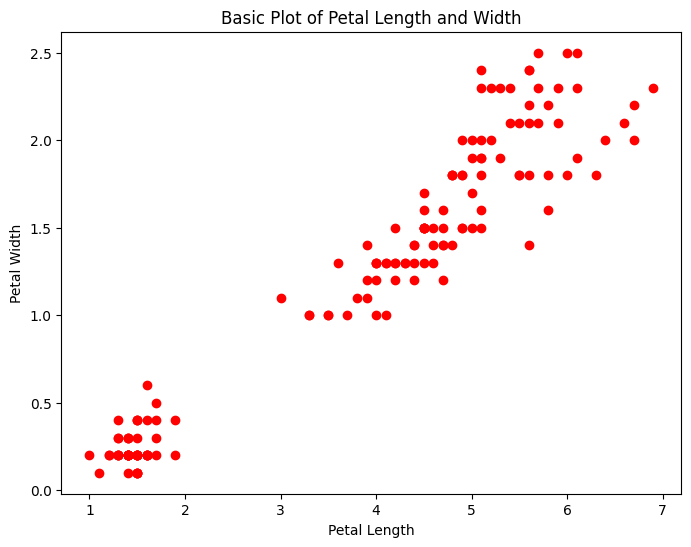

In [39]:
# basic plot to show proof
plt.figure(figsize=(8,6))
plt.scatter(df['petal_length'], df['petal_width'], color = 'red')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Basic Plot of Petal Length and Width')
plt.show()

- The plot shows a linear relationship between petal length and petal width. As petal length increases so does petal width. The plot however doesn't differentiate between species as they are all the same color.
- Customization by hue and palette according to species is done below using Seaborn.

<Axes: xlabel='petal_length', ylabel='petal_width'>

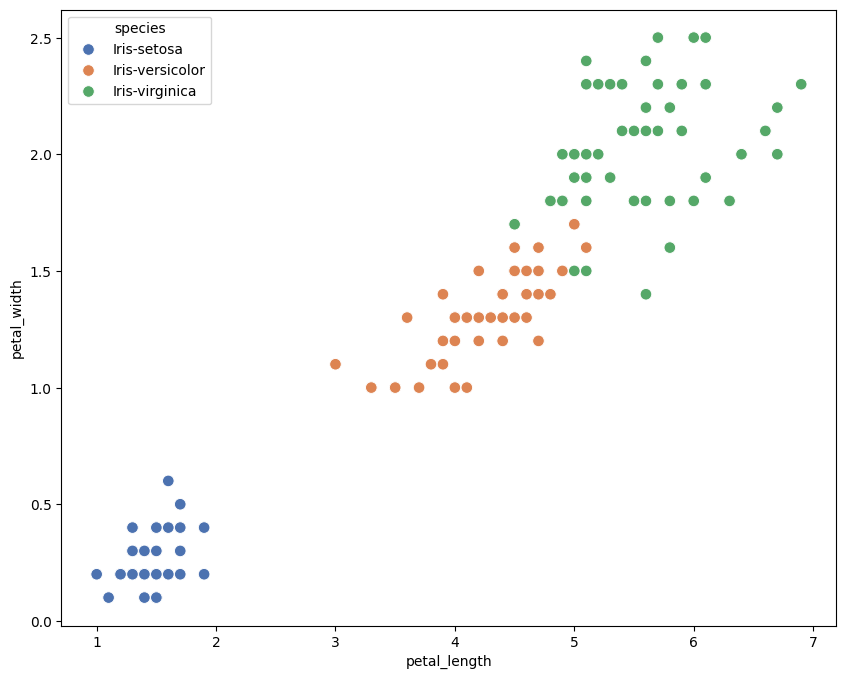

In [21]:
# Using seaborn

x = 'petal_length'
y = 'petal_width'

plt.figure(figsize=(10,8))

sns.scatterplot(data = df, 
                x = x, 
                y = y,
                hue = 'species',
                palette = 'deep',
                s = 70)

- Seaborn provides high-level visualizations with less code while matplotlib allows for more manual customization to produce polished results.
- The plot shows the same linear relationship between petal length and width but importantly, distinguishes them according to species due to the hue = 'species' line of code.
- Therefore, Iris-Virginica has the highest petal length and width measurements, followed by Versicolor, and finally Setosa.

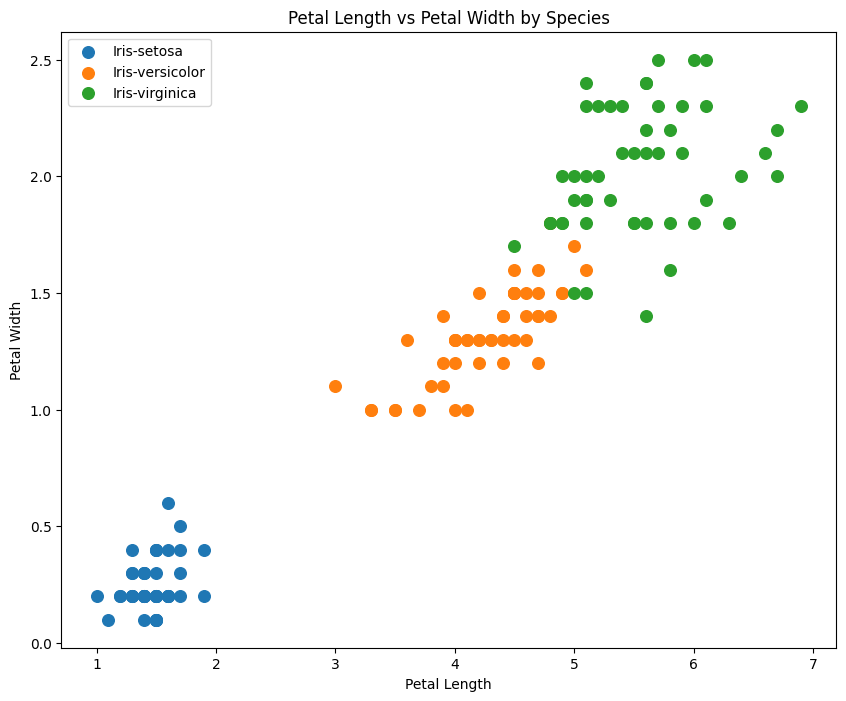

In [22]:
# Same figure as above by using matplotlib
# Petal Length vs Petal Width by Species

plt.figure(figsize=(10, 8))

for species in df['species'].unique():
    subset = df[df['species'] == species]

    plt.scatter(
        subset['petal_length'],
        subset['petal_width'],
        label=species,
        s=70
    )

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Length vs Petal Width by Species')
plt.legend()
plt.show()

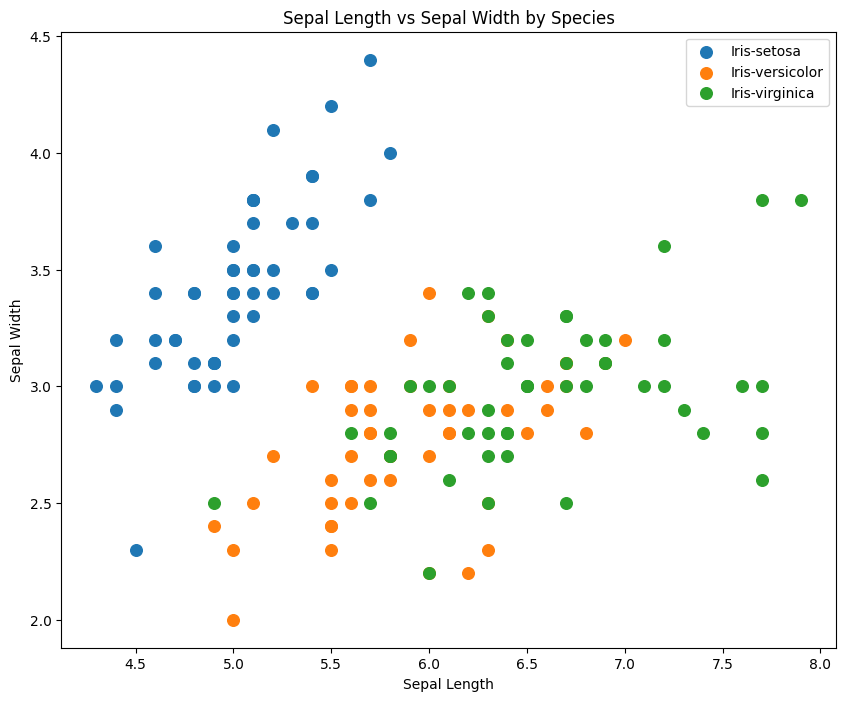

In [23]:
# Sepal Length vs Sepal Width by Species
plt.figure(figsize=(10, 8))

for species in df['species'].unique():
    subset = df[df['species'] == species]

    plt.scatter(
        subset['sepal_length'],
        subset['sepal_width'],
        label=species,
        s=70
    )

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Sepal Length vs Sepal Width by Species')
plt.legend()
plt.show()

#### Boxplots

**What should you look for?**

A box plot lets you compare:

- Median — the line inside the box
- Spread — how wide/tall the box is
- Range — how far the observations extend
- Potential outliers — individual points beyond the whiskers

For the Iris dataset, you'll likely find that petal measurements separate the species much more clearly than sepal measurements. That's an interesting finding to discuss in your project rather than simply saying "I made four box plots."

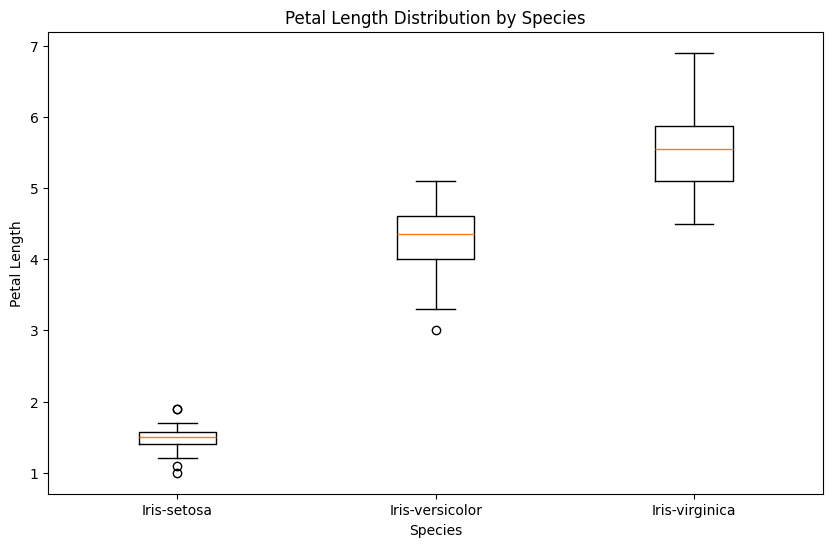

In [24]:
species_labels = df['species'].unique().tolist()

plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[df['species'] == species]['petal_length'] # For each species, give me all of its petal-length values
     for species in df['species'].unique()],
    tick_labels= species_labels
)

plt.xlabel('Species')
plt.ylabel('Petal Length')
plt.title('Petal Length Distribution by Species')

plt.show()

**Why Pylance now complains: This is a separate issue.**  
Your expression: df['species'].unique() - returns a NumPy array.

Pylance sees its type roughly as: np.ndarray[Any]

But Matplotlib's type annotation for tick_labels expects something like: Sequence[str]

In other words, Pylance is saying: "I know you're giving me an array, but I can't prove that this array contains strings."

You and I know that: df['species'].unique()  
produces:  ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

but Pylance isn't necessarily able to infer that as Sequence[str].

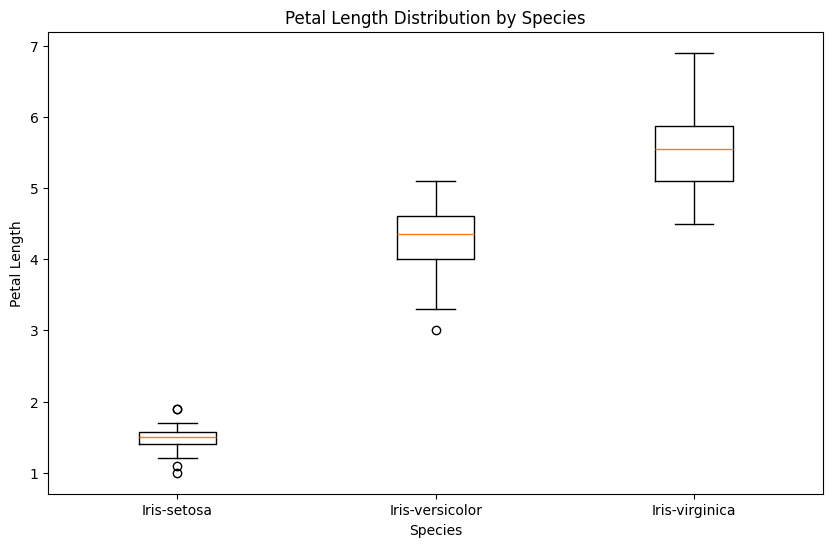

In [25]:
# trying to get rid of the deprecation warning and subsequent Pylance warning
species_labels = df['species'].unique().tolist()

petal_lengths = [
    df[df['species'] == species]['petal_length']
    for species in species_labels
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    petal_lengths,
    tick_labels=species_labels
)

plt.xlabel('Species')
plt.ylabel('Petal Length')
plt.title('Petal Length Distribution by Species')

plt.show()

Why .tolist() helps

Before: df['species'].unique()

→ NumPy array = np.ndarray

After: df['species'].unique().tolist()

→ Python list: list[str]

That's much closer to what Matplotlib's type checker expects.

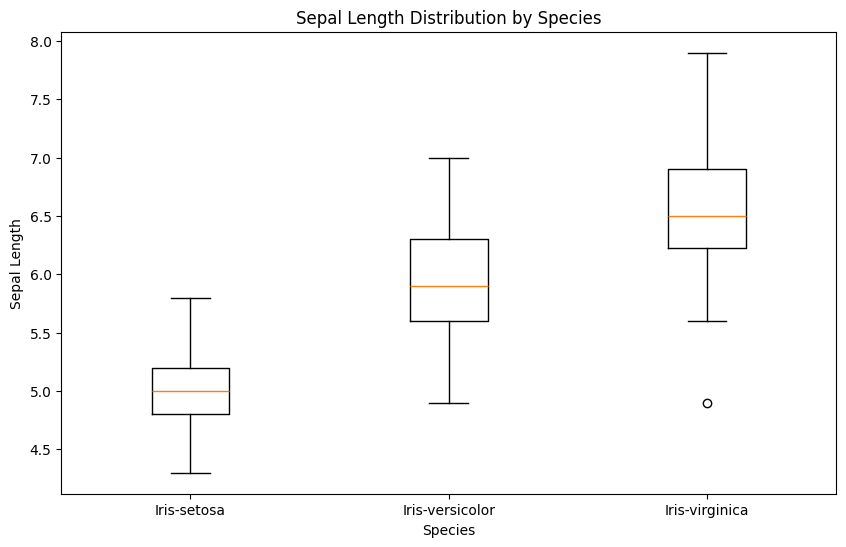

In [26]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[df['species'] == species]['sepal_length'] # For each species, give me all of its sepal-length values
     for species in df['species'].unique()],
    tick_labels= species_labels
)

plt.xlabel('Species')
plt.ylabel('Sepal Length')
plt.title('Sepal Length Distribution by Species')

plt.show()

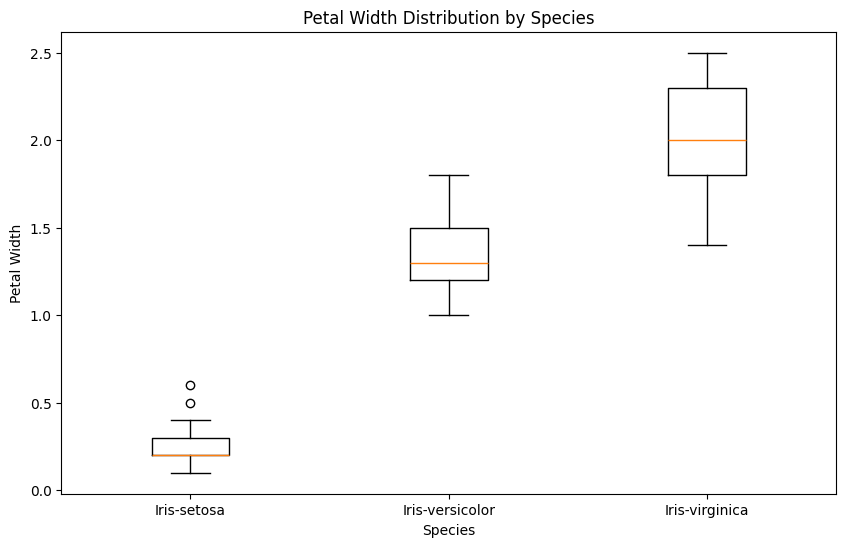

In [27]:
species_labels = df['species'].unique().tolist()

plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[df['species'] == species]['petal_width'] # For each species, give me all of its petal-length values
     for species in df['species'].unique()],
    tick_labels= species_labels
)

plt.xlabel('Species')
plt.ylabel('Petal Width')
plt.title('Petal Width Distribution by Species')

plt.show()

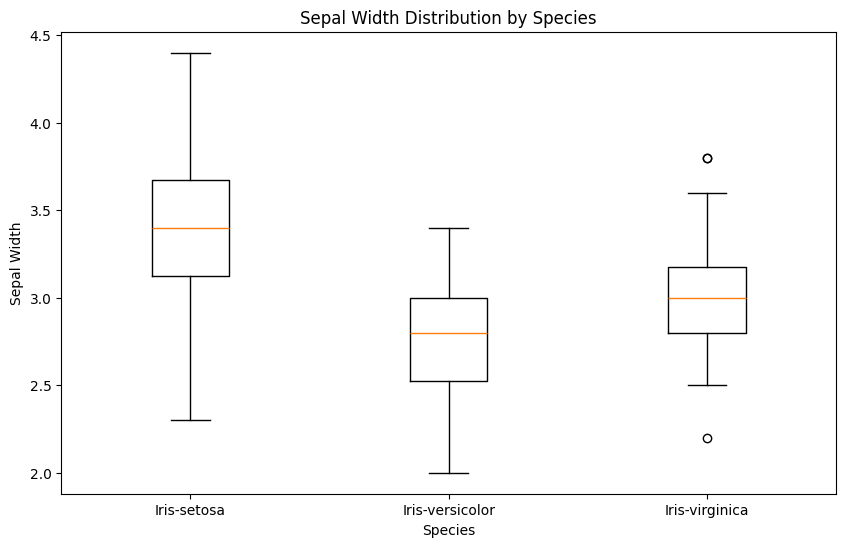

In [28]:
species_labels = df['species'].unique().tolist()

plt.figure(figsize=(10, 6))

plt.boxplot(
    [df[df['species'] == species]['sepal_width'] # For each species, give me all of its petal-length values
     for species in df['species'].unique()],
    tick_labels= species_labels
)

plt.xlabel('Species')
plt.ylabel('Sepal Width')
plt.title('Sepal Width Distribution by Species')

plt.show()

#### Histograms

For your Iris project, the histograms would show the distribution of each numerical measurement:

- sepal_length
- sepal_width
- petal_length
- petal_width

Unlike the box plots, which compare distributions by species, a basic histogram asks:

- **How are the values of this measurement distributed across all 150 Iris flowers?**

*What a histogram shows:*

For example, a histogram of petal_length might have:

- x-axis: Petal length
- y-axis: Number of flowers (frequency)
- bars: Groups/ranges of petal-length values

So you might see many flowers around one range, fewer around another, etc.

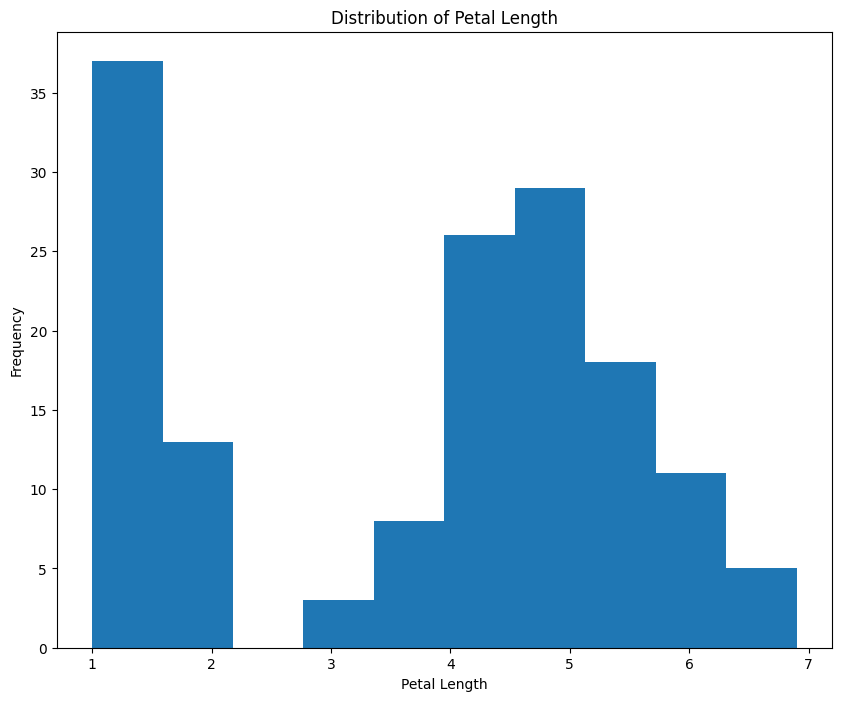

In [29]:
# Histogram of petal length

plt.figure(figsize=(10,8))

plt.hist(df['petal_length'], bins = 10)

plt.xlabel('Petal Length')
plt.ylabel('Frequency')
plt.title('Distribution of Petal Length')

plt.show()

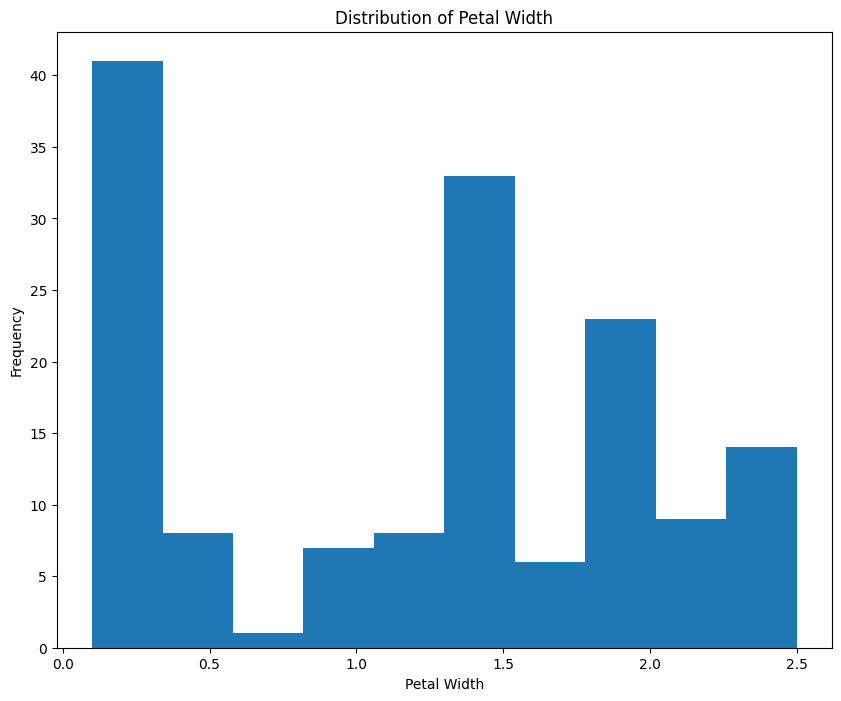

In [30]:
# Histogram of petal width

plt.figure(figsize=(10,8))

plt.hist(df['petal_width'], bins = 10)

plt.xlabel('Petal Width')
plt.ylabel('Frequency')
plt.title('Distribution of Petal Width')

plt.show()

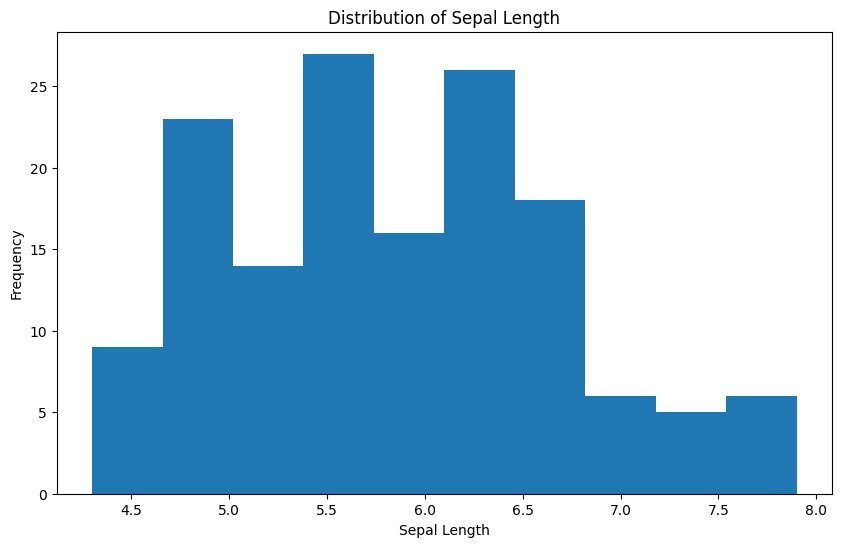

In [31]:
# Histogram of Sepal Length

plt.figure(figsize=(10,6))

plt.hist(df['sepal_length'], bins = 10)

plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Length')
plt.show()

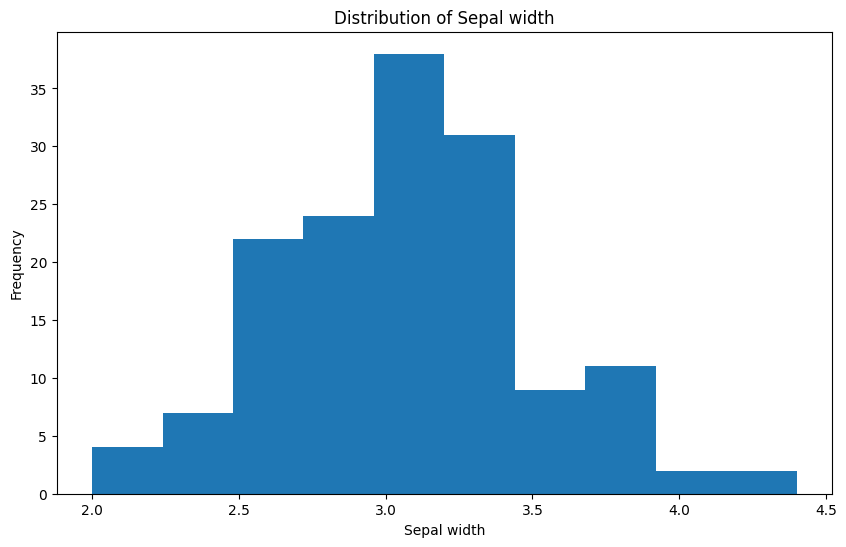

In [32]:
# Histogram of Sepal Width

plt.figure(figsize=(10,6))

plt.hist(df['sepal_width'], bins = 10)

plt.xlabel('Sepal width')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal width')
plt.show()

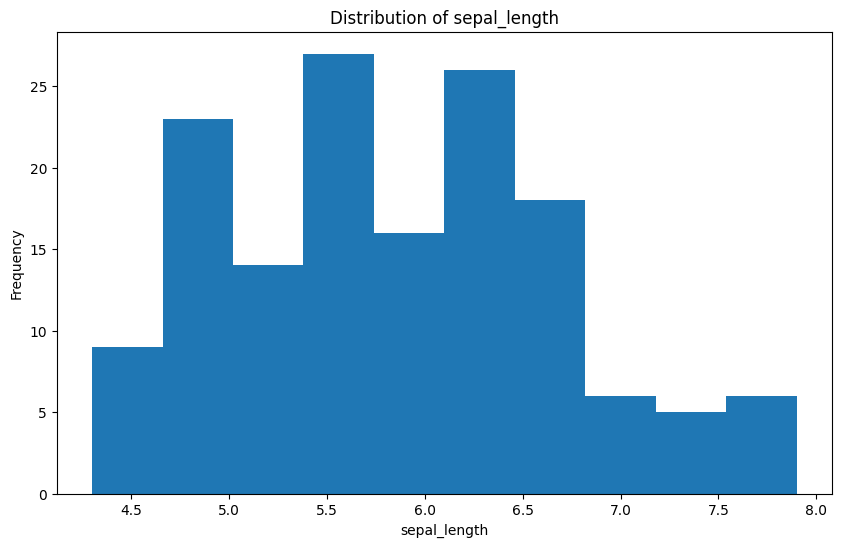

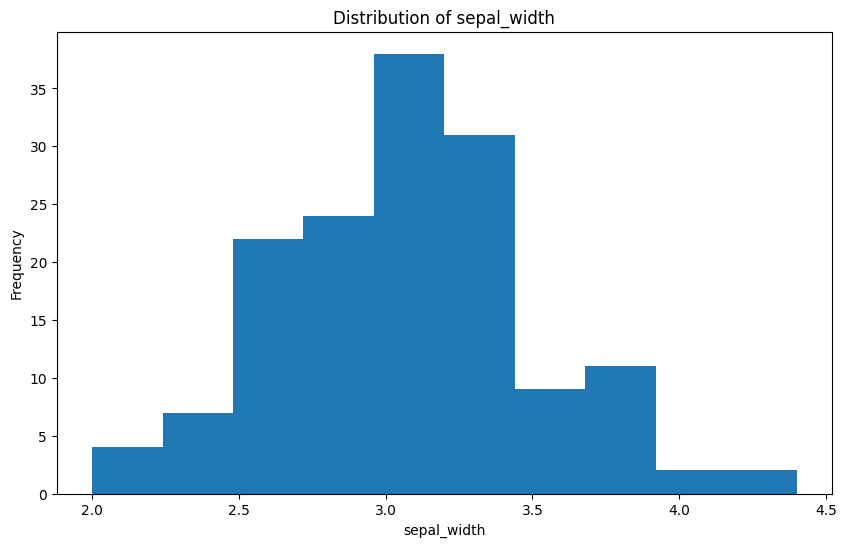

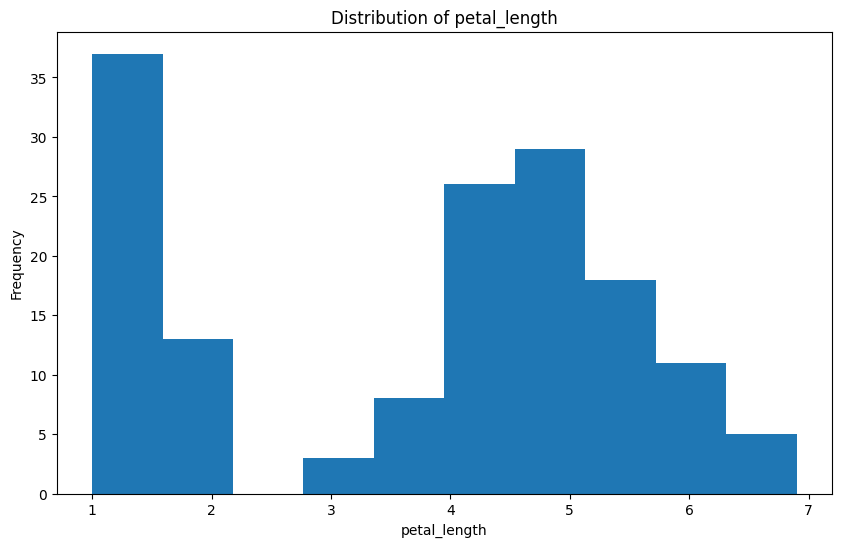

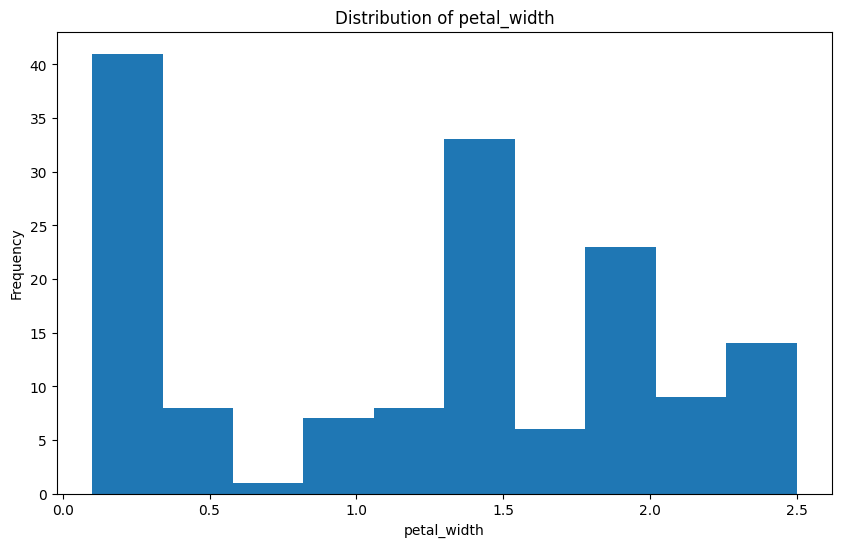

In [33]:
# A more efficient solution for all histogram plots
measurements = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width'
]

for measurement in measurements:

    plt.figure(figsize=(10, 6))

    plt.hist(df[measurement], bins=10)

    plt.xlabel(measurement)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {measurement}')

    plt.show()

What you'll analyze

Once you have the histograms, look for:

- Shape — roughly symmetric, skewed, etc.
- Center — where most observations are concentrated
- Spread — how widely the values are distributed
- Peaks — whether there are one or multiple concentrations of values
- Unusual values — observations that appear far from the main distribution

**And there's a particularly useful observation you may notice with the Iris data: petal measurements can show multiple concentrations because the three species have quite different petal sizes. That connects nicely with your earlier scatter plot and box plots.**

#### Correlation Heatmaps

The question you're asking is:

- How strongly are the different Iris measurements related to one another?

You only want the numerical columns:

- sepal_length
- sepal_width
- petal_length
- petal_width

You don't include species because it is categorical rather than numerical.

In [34]:
correlation_matrix = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()
print(correlation_matrix)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000


The values range from -1 to +1:

- +1 → very strong positive relationship
- 0 → little/no linear relationship
- -1 → very strong negative relationship

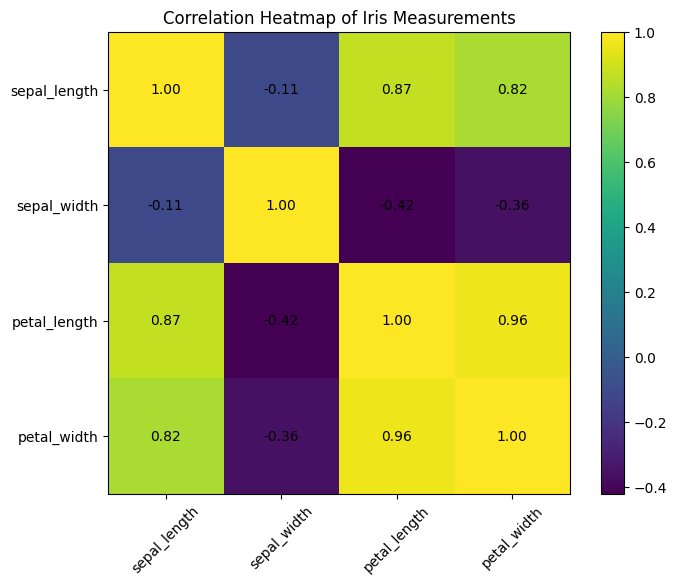

In [35]:
#correlation heatmap

plt.figure(figsize=(8, 6)) #units are in inches

plt.imshow(correlation_matrix)
# imshow() means image show. It displays a 2D array as an image, where different numerical values are represented visually.
# imshow() turns the numbers in the correlation matrix into different shades.

plt.colorbar() # This adds the scale alongside your heatmap. It tells you what the different shades represent numerically.

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
) # "Put the four column names at positions 0, 1, 2, and 3, and rotate those names by 45 degrees."

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)): # i represents the row position
    for j in range(len(correlation_matrix.columns)): # represents the column position
        #This is a nested loop. You're using it to systematically visit every cell in a 2D matrix.
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}', # .iloc means: select something based on its numerical position.
            # The f means this is an f-string, which allows us to insert a value into a string.
            # Display the number as a floating-point number with 2 decimal places.
            ha='center', # horizontal alignment. Center the text horizontally within the cell.
            va='center'  # vertical alignment. Center the text vertically within the cell.
        ) # This puts text inside each cell. 
          # j = x position
          # i = y position
          # So if: i = 2, j = 3 - the text gets placed at column 3, row 2.
          # Because we're inside the loops, the code goes through every cell
plt.title('Correlation Heatmap of Iris Measurements')

plt.show()